# Self Merge Rate - Visualization

The Self Merge Rate graph is defined in the Chaoss Project here: https://chaoss.community/kb/metric-self-merge-rates/

Description of Graphs:

First Graph:

* X-axis: Time (Year)
* Y-axis: Number of PRs

Second Graph:

* X-axis: Time (Year)
* Y-axis: Self-Merge Rate in % (Self merge PRs/Total number of PRs)

The notebook does all the preprocessing down to the visualization enabling many testings and analysis to be done before implementing it on 8Knot


### Importing Libraries

In [ ]:
import sys
import subprocess
import pandas as pd
import sqlalchemy as salc
import json
import os
from pathlib import Path
import datetime as dt
import plotly.graph_objects as go



## Installing Dependencies - Package Management

* This particular implementation uses requirements.txt to install the dependencies

In [96]:
# Package management - Installing requirements.txt
_repo_root = Path.cwd().parent if Path.cwd().name == "wg-data-science" else Path.cwd()
_req_notebook = Path(__file__).parent / "requirements.txt" if "__file__" in dir() else _repo_root / "wg-data-science" / "requirements.txt"
if not _req_notebook.exists():
    _req_notebook = _repo_root / "requirements.txt"


if _req_notebook.exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(_req_notebook)], check=True)
    print("Installed notebook deps from", _req_notebook)
else:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "pandas", "sqlalchemy", "plotly", "psycopg2-binary"],
        check=True,
    )
    print("Installed minimal deps (requirements.txt not found)")

Installed minimal deps (requirements.txt not found)


### Loading Credentials - .env; .json...

In [99]:
# augur_creds.json lives in the same folder as this notebook (8knot/).
# If Jupyter's working directory is augur-analysis/ instead, fall back to 8knot/augur_creds.json.
_cred_path = Path("augur_creds.json")
if not _cred_path.is_file():
    _cred_path = Path("8knot") / "augur_creds.json"
if not _cred_path.is_file():
    raise FileNotFoundError(
        "augur_creds.json should sit next to self_merge_rates.ipynb. "
        f"Not found from cwd: {Path.cwd().resolve()}"
    )
with open(_cred_path) as config_file:
    config = json.load(config_file)

### DB connection

In [102]:
database_connection_string = "postgresql+psycopg2://{}:{}@{}:{}/{}".format(
    config["user"], config["password"], config["host"], config["port"], config["database"]
)
dbschema = "augur_data"
engine = salc.create_engine(
    database_connection_string,
    connect_args={"options": "-csearch_path={}".format(dbschema)},
)

### Queries

Get repo_ids and repo_names from augur data

In [105]:
repo_urls = ["https://github.com/chaoss/augur"]

url_query = str(repo_urls)[1:-1]
repo_query = salc.sql.text(
    f"""
    SET SCHEMA 'augur_data';
    SELECT DISTINCT r.repo_id, r.repo_name
    FROM repo r
    JOIN repo_groups rg ON r.repo_group_id = rg.repo_group_id
    WHERE r.repo_git IN ({url_query})
    """
)
with engine.connect() as conn:
    t = conn.execute(repo_query)
    results = t.all()
repo_ids = [row[0] for row in results]
repo_names = [row[1] for row in results]
print(repo_ids)
print(repo_names)

[36113]
['augur']


Query for Merged PRs

Getting data from selected repos where we get author (cntrb_id): person who opened the PR, merger (merger_cntrb_id): person who merged the PR, created_at and merged_at.

with this info the df or merged-PR table is built

In [ ]:
repo_statement = str(repo_ids)[1:-1]

query = salc.sql.text(f"""
    SELECT
        r.repo_id,
        r.repo_name,
        pr.pull_request_id,
        pr.pr_src_number,
        left(pr.pr_augur_contributor_id::text, 15) AS cntrb_id,
        pr.pr_created_at AS created_at,
        pr.pr_closed_at AS closed_at,
        pr.pr_merged_at AS merged_at,
        left(pre.cntrb_id::text, 15) AS merger_cntrb_id
    FROM repo r
    JOIN pull_requests pr ON r.repo_id = pr.repo_id
    LEFT JOIN pull_request_events pre
        ON pr.pull_request_id = pre.pull_request_id AND pre.action = 'merged'
    WHERE r.repo_id IN ({repo_statement})
        AND pr.pr_created_at < now()
        AND (pr.pr_closed_at < now() OR pr.pr_closed_at IS NULL)
        AND (pr.pr_merged_at < now() OR pr.pr_merged_at IS NULL)
    ORDER BY pr.pr_created_at
""")
df = pd.read_sql(query, con=engine)
df = df.reset_index()
df.drop("index", axis=1, inplace=True)

# filter to only merged PRs for self-merge analysis
df = df[df["merged_at"].notna() & (df["merged_at"] != "")]

df["merged_at"] = pd.to_datetime(df["merged_at"], utc=True)
df["created_at"] = pd.to_datetime(df["created_at"], utc=True)

### Optional filters (lines changed, file type, review volume)

There is also the option of adding filters into the graphs

The options are:

* Only consider PRs with a specified minimal number of lines changed
* Only consider PRs with a specified maximal number of lines changed
* Only PRs with a certain amount of reviews
* Only PRs with a specific file type

Default is None, so no filter is applied initially

In [130]:
# Optional: set to None to skip filter; otherwise only PRs passing the filter are used for the rate.
FILTER_MIN_LINES = 50 # e.g. 10  -> only PRs with at least this many lines changed
FILTER_MAX_LINES = 100   # e.g. 500 -> only PRs with at most this many lines changed
FILTER_MIN_REVIEWS = None  # e.g. 1  -> only PRs with at least this many reviews
FILTER_FILE_TYPE = None   # None | "code" | "docs" -> restrict to PRs that touch code, or only docs

repo_statement_f = str(repo_ids)[1:-1]
optional_query = salc.sql.text(f"""
    WITH pr_lines AS (
        SELECT
            prc.pull_request_id,
            COALESCE(SUM(c.cmt_added) + SUM(c.cmt_removed), 0)::int AS lines_changed,
            COUNT(DISTINCT c.cmt_filename) FILTER (WHERE c.cmt_filename ~ '\\.(md|rst|txt|adoc|mdx)$') AS doc_files,
            COUNT(DISTINCT c.cmt_filename) AS total_files
        FROM pull_request_commits prc
        JOIN commits c ON c.cmt_id = prc.pr_cmt_id
        JOIN pull_requests pr ON pr.pull_request_id = prc.pull_request_id AND pr.repo_id IN ({repo_statement_f})
        GROUP BY prc.pull_request_id
    ),
    pr_reviews AS (
        SELECT pull_request_id, COUNT(*) AS review_count
        FROM pull_request_reviews
        WHERE repo_id IN ({repo_statement_f})
        GROUP BY pull_request_id
    )
    SELECT
        pl.pull_request_id,
        pl.lines_changed,
        pl.doc_files,
        pl.total_files,
        COALESCE(pr.review_count, 0)::int AS review_count
    FROM pr_lines pl
    LEFT JOIN pr_reviews pr ON pr.pull_request_id = pl.pull_request_id
""")
opt_df = pd.read_sql(optional_query, con=engine)
df = df.merge(opt_df, on="pull_request_id", how="left")
df["lines_changed"] = df["lines_changed"].fillna(0).astype(int)
df["review_count"] = df["review_count"].fillna(0).astype(int)
# Code vs docs: code = at least one non-doc file; docs = only doc files (or no files)
df["is_docs_only"] = (df["total_files"].fillna(0) > 0) & (df["doc_files"].fillna(0) >= df["total_files"].fillna(0))

mask = pd.Series(True, index=df.index)
if FILTER_MIN_LINES is not None:
    mask &= df["lines_changed"] >= FILTER_MIN_LINES
if FILTER_MAX_LINES is not None:
    mask &= df["lines_changed"] <= FILTER_MAX_LINES
if FILTER_MIN_REVIEWS is not None:
    mask &= df["review_count"] >= FILTER_MIN_REVIEWS
if FILTER_FILE_TYPE == "code":
    mask &= ~df["is_docs_only"]
elif FILTER_FILE_TYPE == "docs":
    mask &= df["is_docs_only"]
df = df[mask].copy()
print(f"PRs after optional filters: {len(df)}")

PRs after optional filters: 176


### Data Processing

In [132]:
df

,repo_id,repo_name,pull_request_id,pr_src_number,cntrb_id,created_at,merged_at,merger_cntrb_id,lines_changed,doc_files,total_files,review_count,is_docs_only
10,36113,augur,1104301,32,010005cb-c700-0,2017-03-16 21:16:33+00:00,2017-03-16 21:17:07+00:00,010005cb-c700-0,64,0.0,4.0,0,False
20,36113,augur,1104663,83,010143e0-bf00-0,2018-03-01 20:38:03+00:00,2018-03-01 22:16:53+00:00,01000cc1-1000-0,65,0.0,1.0,0,False
34,36113,augur,1103982,167,010005cb-c700-0,2018-09-04 19:22:59+00:00,2018-09-04 19:23:17+00:00,010005cb-c700-0,91,0.0,1.0,0,False
35,36113,augur,1103688,168,010005cb-c700-0,2018-09-04 19:30:51+00:00,2018-09-04 19:31:40+00:00,010005cb-c700-0,78,0.0,1.0,0,False
37,36113,augur,1104577,173,01021550-ba00-0,2018-09-18 19:23:16+00:00,2018-10-12 17:34:57+00:00,01000cc1-1000-0,56,0.0,4.0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1664,36113,augur,463660854,2972,010005cb-c700-0,2025-01-15 00:50:41+00:00,2025-01-21 23:51:34+00:00,010005cb-c700-0,52,0.0,13.0,5,False
1673,36113,augur,478984521,2989,010005cb-c700-0,2025-02-12 02:35:22+00:00,2025-02-12 02:47:32+00:00,010005cb-c700-0,52,0.0,13.0,0,False
1711,36113,augur,516013444,3125,010005cb-c700-0,2025-04-09 17:52:53+00:00,2025-04-09 17:53:02+00:00,010005cb-c700-0,96,0.0,24.0,0,False
1729,36113,augur,516013390,3175,010005cb-c700-0,2025-06-07 23:21:03+00:00,2025-06-08 00:17:00+00:00,010005cb-c700-0,76,0.0,19.0,2,False


In [116]:
INTERVAL = "M"

Here is where we compare repos checking for self-merge numbers.

Self-merge happens when the cntrb_id == merger_cntrb_id

Dataframes are created to hold specific values:

* df_merged holds the values of total number of PRs merged

* df_self holds the values of only self_merged PRs

* Then, df_plot is defined, with the information from total number of PRs merged, self merged, and the rate in percentage of self merged rates

In [136]:
# Self-merge: author == merger (with safe handling of nulls)
df["cntrb_id"] = df["cntrb_id"].astype(str)
df["merger_cntrb_id"] = df["merger_cntrb_id"].fillna("").astype(str)
df["is_self_merge"] = (df["cntrb_id"] == df["merger_cntrb_id"]) & (df["merger_cntrb_id"] != "")

# Period slice for date formatting
period_slice = 10 if INTERVAL == "W" else (4 if INTERVAL == "Y" else 7)

# Counts per period by merged_at
merged_range = df["merged_at"].dt.to_period(INTERVAL).value_counts().sort_index()
df_merged = merged_range.to_frame().reset_index().rename(columns={"merged_at": "Date", "count": "total_merged"})
df_merged["Date"] = pd.to_datetime(df_merged["Date"].astype(str).str[:period_slice])

self_merge_range = df[df["is_self_merge"]]["merged_at"].dt.to_period(INTERVAL).value_counts().sort_index()
df_self = self_merge_range.to_frame().reset_index().rename(columns={"merged_at": "Date", "count": "self_merged"})
df_self["Date"] = pd.to_datetime(df_self["Date"].astype(str).str[:period_slice])

df_plot = df_merged.merge(df_self, on="Date", how="outer").fillna(0)
df_plot["self_merged"] = df_plot["self_merged"].astype(int)
df_plot["rate_pct"] = (df_plot["self_merged"] / df_plot["total_merged"].replace(0, float("nan")) * 100).round(1)


if INTERVAL == "M":
    df_plot["Date_str"] = pd.to_datetime(df_plot["Date"]).dt.strftime("%Y-%m-01")
elif INTERVAL == "Y":
    df_plot["Date_str"] = pd.to_datetime(df_plot["Date"]).dt.strftime("%Y-01-01")
else:
    df_plot["Date_str"] = pd.to_datetime(df_plot["Date"]).dt.strftime("%Y-%m-%d")

df_plot = df_plot.sort_values("Date").reset_index(drop=True)
df_plot

/var/folders/18/h5j8yr7143s1k99dktd_kyz00000gn/T/ipykernel_4148/1708474825.py:10: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.

/var/folders/18/h5j8yr7143s1k99dktd_kyz00000gn/T/ipykernel_4148/1708474825.py:14: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



,Date,total_merged,self_merged,rate_pct,Date_str
0,2017-03-01,1,1,100.0,2017-03-01
1,2018-03-01,1,0,0.0,2018-03-01
2,2018-09-01,2,2,100.0,2018-09-01
3,2018-10-01,1,0,0.0,2018-10-01
4,2019-01-01,1,0,0.0,2019-01-01
...,...,...,...,...,...
59,2025-01-01,2,2,100.0,2025-01-01
60,2025-02-01,1,1,100.0,2025-02-01
61,2025-04-01,1,1,100.0,2025-04-01
62,2025-06-01,1,1,100.0,2025-06-01


### Plots

Charts use the same filtered dataset (time aggregation + any optional filters applied above).

## Self Merge Rates

The first graph will display the number of PRs merged over time (years), where we have two curves:

* Total number of merged PRs
* Self merged PRs

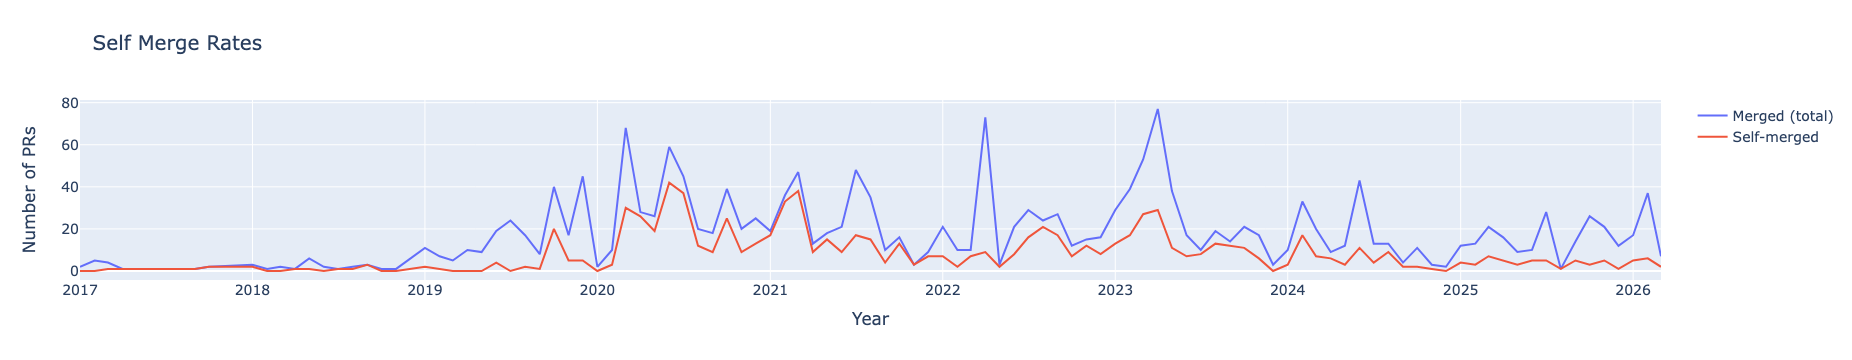

In [ ]:
fig = go.Figure(
    [
        go.Scatter(
            name="Merged (total)",
            x=df_plot["Date_str"],
            y=df_plot["total_merged"],
            mode="lines",
            showlegend=True,
            hovertemplate="Merged (total): %{y}<br>%{x|%b %d, %Y} <extra></extra>",
        ),
        go.Scatter(
            name="Self-merged",
            x=df_plot["Date_str"],
            y=df_plot["self_merged"],
            mode="lines",
            showlegend=True,
            hovertemplate="Self-merged: %{y}<br>%{x|%b %d, %Y} <extra></extra>",
        ),
    ]
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of PRs",
    font=dict(size=14),
    title="Self Merge Rates",
)

## Self Merge Rate (%) 

The second graph shows the ratio between the self-merged PRs over the total number of PRs across the same interval of time 

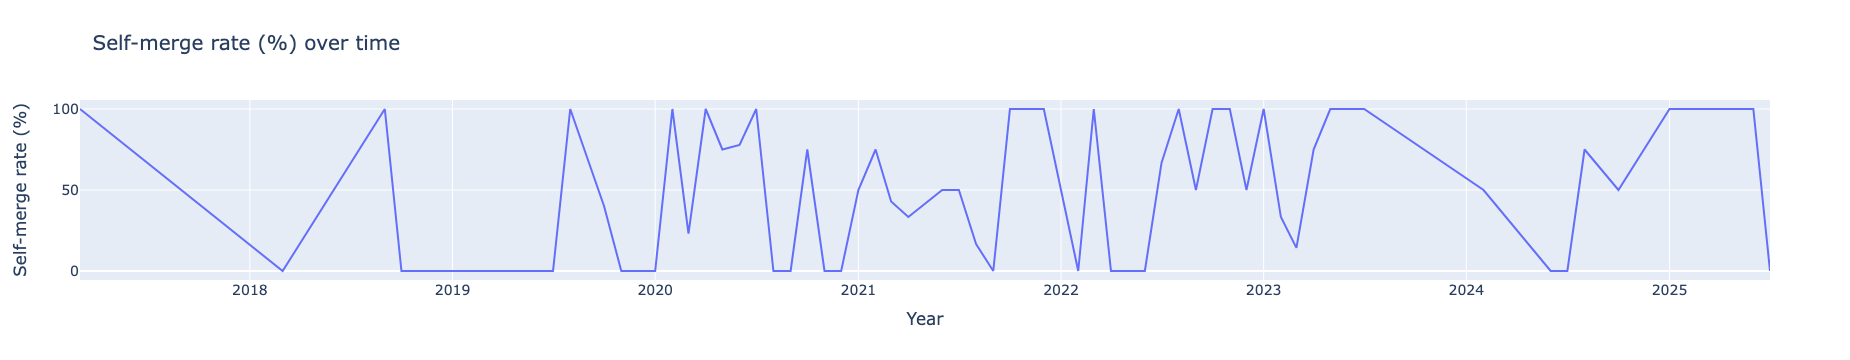

In [ ]:
fig_rate = go.Figure()
fig_rate.add_trace(
    go.Scatter(
        x=df_plot["Date_str"],
        y=df_plot["rate_pct"],
        mode="lines",
        name="Self-merge rate (%)",
        marker=dict(size=6),
        hovertemplate="%{x}<br>Rate: %{y:.1f}%<extra></extra>",
    )
)
fig_rate.update_layout(
    title="Self-merge rate (%) over time",
    xaxis_title="Year",
    yaxis_title="Self-merge rate (%)",
    font=dict(size=14),
)
fig_rate.show()